# Conformal envelopes (generated data)

We simulate two labels, A and B, and four predictors for each candidate label:

Scores lie between 0 and 1; higher means stronger evidence for that candidate (simulated scores, not fitted or calibrated probabilities). A and B each have their own score columns, supplied through `label_to_columns`. 

Training and test data are independent draws from the same generator. Test labels are used only for evaluation.

In [1]:
import sys
from pathlib import Path
from time import perf_counter
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


LIBRARY_PARENT = None
if LIBRARY_PARENT is not None:
    sys.path.insert(0, str(Path(LIBRARY_PARENT).resolve()))
else:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "conformal_envelopes" / "__init__.py").is_file():
            sys.path.insert(0, str(parent))
            break

from conformal_envelopes import ConformalSetModel, evaluate_prediction_sets
import conformal_envelopes
print("Library:", conformal_envelopes.__file__)

Library: /home/siddiqun/Bureau/Conformal Library/conformal_envelopes/__init__.py


## Settings

In [2]:
SEED = 13
ALPHA = 0.10              # target miscoverage level
N_TRAIN = 1500            # number of training points
N_TEST = 500              # number of test points
MISSING_RATE = 0.15       # probability of hiding each score
CORRELATION = 0.90        # correlation between the good and correlated 
GOOD_SIGNAL = 1.8         # strength of the label dependent shift for the strong predictors
WEAK_SIGNAL = 0.35        # smaller label-dependent shift for the weak predicto

In [3]:
CLASSES = ["A", "B"]

## - good: strong evidence about whether the candidate label is correct or not 
## - correlated: strong evidence, very similar to good
## - weak: a little useful evidence
## - noise: no useful evidence
PREDICTORS = ["good", "correlated", "weak", "noise"] 

# tells the library which columns to use while asessing each candidate
label_to_columns = {label: [f"{label}_{name}" for name in PREDICTORS] for label in CLASSES}
score_cols = [c for label in CLASSES for c in label_to_columns[label]]
METHOD_PARAMS = {"collapsed": {},
                 "radial": {"n_directions": 100, "smoothing": 4.0, 
                            "angle_deg": 30.0, "neighbor_fraction": 0.2},
                 "strip": {"n_bins": 8, "min_samples": 3},}

## Generating the data
Using the simulated label to create the joint distribution of labels and scores. 

In [4]:
def generate_data(n, rng, prefix):
    #checking invalid parameters
    if not 0 <= MISSING_RATE < 1:
        raise ValueError("MISSING_RATE must be in [0, 1).")
    if not -1 <= CORRELATION <= 1:
        raise ValueError("CORRELATION must be in [-1, 1].")

    # generating true labels and IDs
    labels = rng.choice(CLASSES, size=n)
    # creating IDs
    clean = pd.DataFrame({"ID": [f"{prefix}_{i:05d}" for i in range(n)]})

    # loop runs once for each candidate
    for label, columns in label_to_columns.items():
        # assigns whether the candidate matches the true label or not
        sign = np.where(labels == label, 1.0, -1.0)
        # creating noise
        z = rng.normal(size=n)
        z_correlated = (CORRELATION * z + np.sqrt(1 - CORRELATION**2) * rng.normal(size=n))
        latent = np.column_stack([GOOD_SIGNAL * sign + z, GOOD_SIGNAL * sign + z_correlated, 
                                  WEAK_SIGNAL * sign + rng.normal(0, 1.5, size=n),])
        # converting scores to [0,1] and generting a 4th predictor which is just noise
        values = np.column_stack([1 / (1 + np.exp(-latent)),  rng.uniform(0, 1, size=n),])
        clean[columns] = values

    # keeping the labels and creatign missing data
    clean["label"] = labels
    observed = clean.copy()
    for columns in label_to_columns.values():
        mask = rng.random((n, len(columns))) < MISSING_RATE
        empty = mask.all(axis=1)
        while empty.any():
            mask[empty] = rng.random((int(empty.sum()), len(columns))) < MISSING_RATE
            empty = mask.all(axis=1)
        observed[columns] = observed[columns].mask(mask)
    return observed, clean

In [5]:
train_seed, test_seed = np.random.SeedSequence(SEED).spawn(2)
train, train_complete = generate_data(N_TRAIN, np.random.default_rng(train_seed), "train")
test, test_complete = generate_data(N_TEST, np.random.default_rng(test_seed), "test")

assert set(train.ID).isdisjoint(test.ID)
for columns in label_to_columns.values():
    # check that IDs do not overlap
    assert train[columns].notna().any(axis=1).all()
    assert test[columns].notna().any(axis=1).all()

print("Training rows:", len(train), "| Test rows:", len(test))
display(train.head())
display(pd.DataFrame({"train": train.label.value_counts(),
                      "test": test.label.value_counts()}))
display(train[score_cols].isna().mean().rename("missing_fraction").to_frame())

Training rows: 1500 | Test rows: 500


,ID,A_good,A_correlated,A_weak,A_noise,B_good,B_correlated,B_weak,B_noise,label
0,train_00000,NaN,0.766787,0.359347,0.819924,0.115727,0.111806,0.453038,0.847067,A
1,train_00001,0.048254,0.057168,0.635967,0.272490,0.959029,0.937700,0.407228,NaN,B
2,train_00002,0.051622,NaN,0.246120,0.639924,0.840745,NaN,0.228667,0.251282,B
3,train_00003,0.949841,0.968016,0.581315,0.247936,0.339182,NaN,0.736548,0.619160,A
4,train_00004,0.156117,0.310749,0.486802,0.263050,0.776872,0.730257,0.031488,0.087288,B


,train,test
label,,
B,760,259
A,740,241


,missing_fraction
A_good,0.143333
A_correlated,0.156000
A_weak,0.160000
A_noise,0.150000
B_good,0.142000
B_correlated,0.146667
B_weak,0.154000
B_noise,0.144667


## Checking if the predictors behave as intended
Using training data only. Within-class correlations distinguish shared predictor noise from correlation caused simply by separating A and B.

,A_good,A_correlated,A_weak,A_noise
label,,,,
A,0.824,0.826,0.548,0.515
B,0.180,0.179,0.421,0.505


Candidate A scores, true class A: correlations


,A_good,A_correlated,A_weak,A_noise
A_good,1.00,0.88,0.05,-0.07
A_correlated,0.88,1.00,0.04,-0.06
A_weak,0.05,0.04,1.00,-0.05
A_noise,-0.07,-0.06,-0.05,1.00


Candidate A scores, true class B: correlations


,A_good,A_correlated,A_weak,A_noise
A_good,1.00,0.89,0.02,0.04
A_correlated,0.89,1.00,-0.00,0.06
A_weak,0.02,-0.00,1.00,0.01
A_noise,0.04,0.06,0.01,1.00


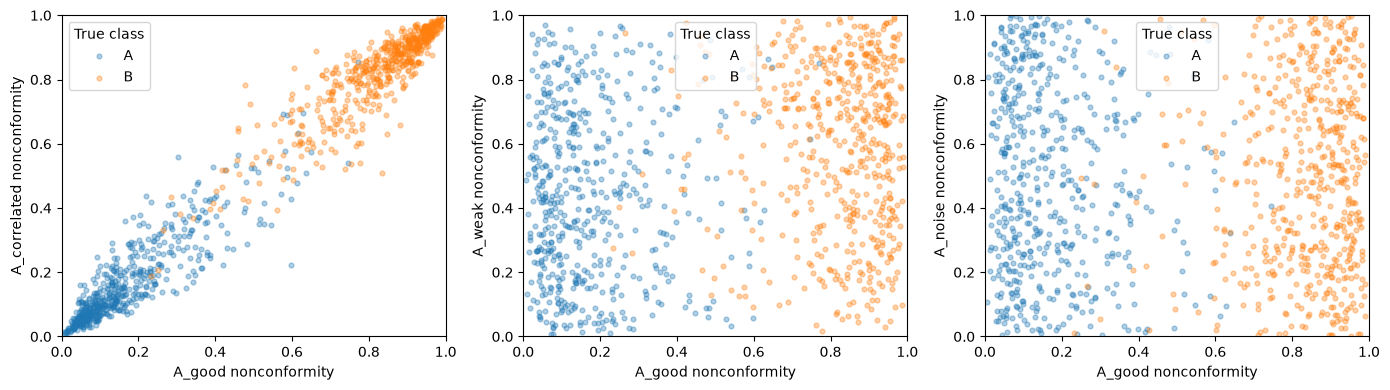

In [6]:
candidate = "A"
columns = label_to_columns[candidate]
# computes mean A scores separately for true-A and true-B observations.
display(train_complete.groupby("label")[columns].mean().round(3))
for true_label in CLASSES:
    print(f"Candidate A scores, true class {true_label}: correlations")
    display(train_complete.loc[train_complete.label.eq(true_label), columns].corr().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {"A": "tab:blue", "B": "tab:orange"}
for ax, second in zip(axes, ["correlated", "weak", "noise"]):
    for label in CLASSES:
        rows = train.loc[train.label.eq(label)]
        ax.scatter(1-rows.A_good, 1-rows[f"A_{second}"], s=12, alpha=0.35, color=colors[label], label=label)
    ax.set(xlabel="A_good nonconformity", ylabel=f"A_{second} nonconformity", xlim=(0, 1), ylim=(0, 1))
    ax.legend(title="True class")
plt.tight_layout()
plt.show()

## Fitting and evaluating all three methods
Each method fits one envelope per label. 
- The library splits training rows into shape discovery S1 and calibration S2. 
- NaNs remain NaNs: we do not fill them with zeros. 
- Forced predictions are disabled so empty sets remain visible.

- Coverage is the fraction of test prediction sets containing the true label. 
- Set size measures ambiguity.

In [7]:
models = {}
predictions = {}
summary = []

# runs teh same procedure for all the methods
for method, parameters in METHOD_PARAMS.items():
    model = ConformalSetModel(method=method, alpha=ALPHA, random_state=SEED,
                              score_direction="higher_is_better", shape_fraction=0.5,
                              force_nonempty=False, **parameters,)
    start = perf_counter()

    # recieves the training labels and candidate specific score mappings - one envelope per label
    model.fit(train, id_col="ID", label_col="label", score_cols=score_cols,
              label_to_columns=label_to_columns)
    fit_seconds = perf_counter() - start
    start = perf_counter()

    # predicting (without teh test labels)
    result = model.predict(test.drop(columns="label"))
    predict_seconds = perf_counter() - start
    truth = test.set_index("ID").loc[result["ID"], "label"].tolist()

    # calculating the metrics
    metrics = evaluate_prediction_sets(result["prediction_set"], truth)
    summary.append({"method": method, **metrics, "fit_seconds": fit_seconds, 
                    "predict_seconds": predict_seconds, "forced": int(result["forced"].sum())})
    models[method] = model
    predictions[method] = result

summary = pd.DataFrame(summary).set_index("method")
display(summary.round(4))
print("Nominal target:", 1-ALPHA)

,coverage,average_set_size,singleton_rate,singleton_accuracy,empty_rate,per_class_coverage,fit_seconds,predict_seconds,forced
method,,,,,,,,,
collapsed,0.858,0.950,0.79,0.9848,0.130,"{'B': 0.8841698841698842, 'A': 0.8298755186721...",0.0067,0.0316,0
radial,0.880,1.014,0.79,0.9722,0.098,"{'B': 0.8841698841698842, 'A': 0.8755186721991...",0.0538,0.0622,0
strip,0.888,0.944,0.84,0.9952,0.108,"{'B': 0.8918918918918919, 'A': 0.8838174273858...",0.0336,0.0301,0


Nominal target: 0.9


In [8]:
class_rows = []
for method, result in predictions.items():
    truth = test.set_index("ID").loc[result.ID, "label"].to_numpy()
    covered = np.array([y in labels for y, labels in zip(truth, result.prediction_set)])
    for label in CLASSES:
        selected = truth == label
        class_rows.append({"method": method, "label": label, "n_test": int(selected.sum()),
                           "coverage": covered[selected].mean(),
                           "mean_set_size": result.loc[selected, "set_size"].mean()})
display(pd.DataFrame(class_rows).round(4))

,method,label,n_test,coverage,mean_set_size
0,collapsed,A,241,0.8299,0.9336
1,collapsed,B,259,0.8842,0.9653
2,radial,A,241,0.8755,1.0083
3,radial,B,259,0.8842,1.0193
4,strip,A,241,0.8838,0.9212
5,strip,B,259,0.8919,0.9653


## Inspecting envelopes and prediction sets
The dictionary below gives one conformal set per test ID.

In [9]:
envelope_rows = []
for method, model in models.items():
    for label, info in model.get_envelopes().items():
        envelope_rows.append({"method": method, "label": label, "shape_n": info["shape_size"],
                              "calibration_n": info["calibration_size"],
                              "t_hat": info["envelope"]["t_hat"]})
display(pd.DataFrame(envelope_rows))

,method,label,shape_n,calibration_n,t_hat
0,collapsed,A,370,370,0.938280
1,collapsed,B,380,380,0.967165
2,radial,A,370,370,0.968079
3,radial,B,380,380,0.957717
4,strip,A,370,370,0.994412
5,strip,B,380,380,0.973892


In [10]:
result = predictions["strip"]
display(result[["ID", "prediction_set", "set_size", "forced"]].head(10))

,ID,prediction_set,set_size,forced
0,test_00000,[B],1,False
1,test_00001,[A],1,False
2,test_00002,"[A, B]",2,False
3,test_00003,[B],1,False
4,test_00004,[A],1,False
5,test_00005,[B],1,False
6,test_00006,[B],1,False
7,test_00007,[B],1,False
8,test_00008,[B],1,False
9,test_00009,[A],1,False


In [11]:
prediction_sets_by_id = dict(zip(result.ID, result.prediction_set))
print(dict(list(prediction_sets_by_id.items())[:5]))

{'test_00000': ['B'], 'test_00001': ['A'], 'test_00002': ['A', 'B'], 'test_00003': ['B'], 'test_00004': ['A']}


## Plotting envelopes in nonconformity space
The library stores only each class's assigned columns. Therefore, to show other classes under candidate-specific mappings, we overlay their observed points from the full training frame here; we do not ask the library for columns it did not store. All points use the selected candidate's score columns.

In [12]:
PLOT_LABEL = "B"       # "A" or "B"
x = f"{PLOT_LABEL}_good"   # "good", "correlated", "weak", or "noise"
y = f"{PLOT_LABEL}_weak"

#### Slice of the full envelope; other coordinates fixed at training medians. Point categories use full-model decisions

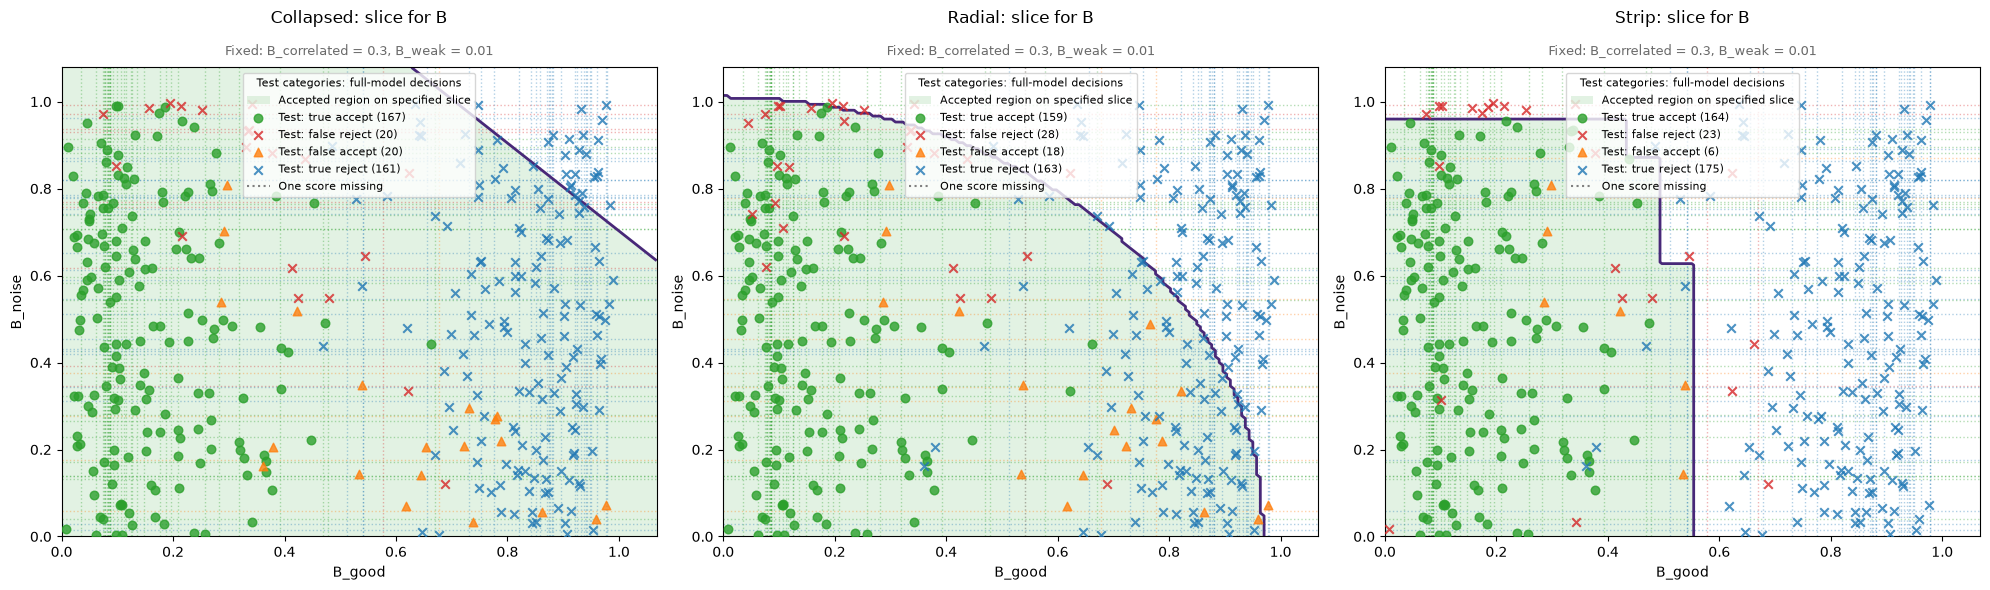

In [14]:
PLOT_LABEL = "B"  # "A" or "B"

X_PREDICTOR = "good"    # "good" or "correlated" or "weak" or "noise"
Y_PREDICTOR = "noise"

# Fixed nonconformity values for the two hidden predictors.
SLICE_VALUES = {"correlated": 0.3, "weak": 0.01,}

x = f"{PLOT_LABEL}_{X_PREDICTOR}"
y = f"{PLOT_LABEL}_{Y_PREDICTOR}"

slice_values = {f"{PLOT_LABEL}_{predictor}": value
                for predictor, value in SLICE_VALUES.items()}

plot_test = test.copy()

fig, axes = plt.subplots(1, len(models), figsize=(20, 6), squeeze=False,)

for ax, (model_name, model) in zip(axes.ravel(), models.items()):
    model.plot_slice(x=x, y=y, label=PLOT_LABEL, test_data=plot_test,
                     slice_values=slice_values, show_training=False,
                     show_missing=True, ax=ax,)
    # ax.set_title(f"{model_name.capitalize()} — {PLOT_LABEL}")

plt.tight_layout()
plt.show()

#### Separate 2D fit; point categories use the 2D envelope

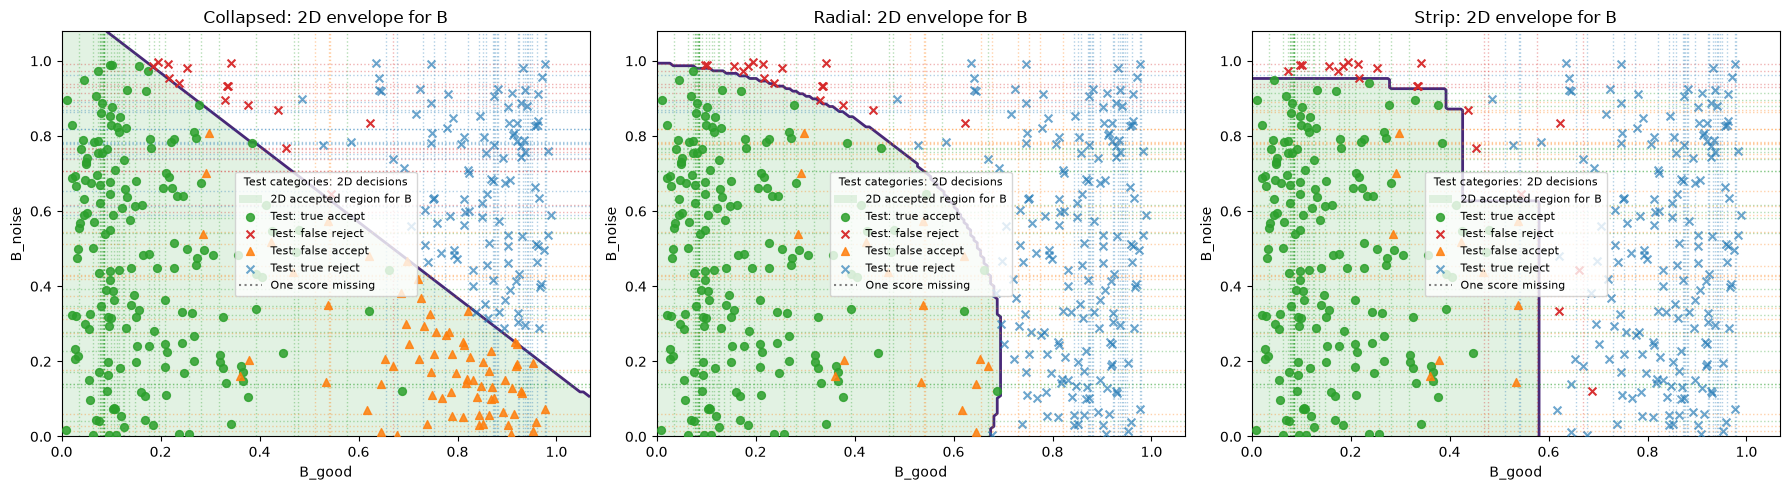

In [15]:
plot_test = test.copy()

fig, axes = plt.subplots(1, len(models), figsize=(18, 5), squeeze=False)

for ax, model in zip(axes.ravel(), models.values()):
    model.plot(x=x, y=y, label=PLOT_LABEL, test_data=plot_test, show_training=False, 
               show_other_classes=False, show_missing=True, ax=ax,)

plt.tight_layout()
plt.show()

## Heatmaps

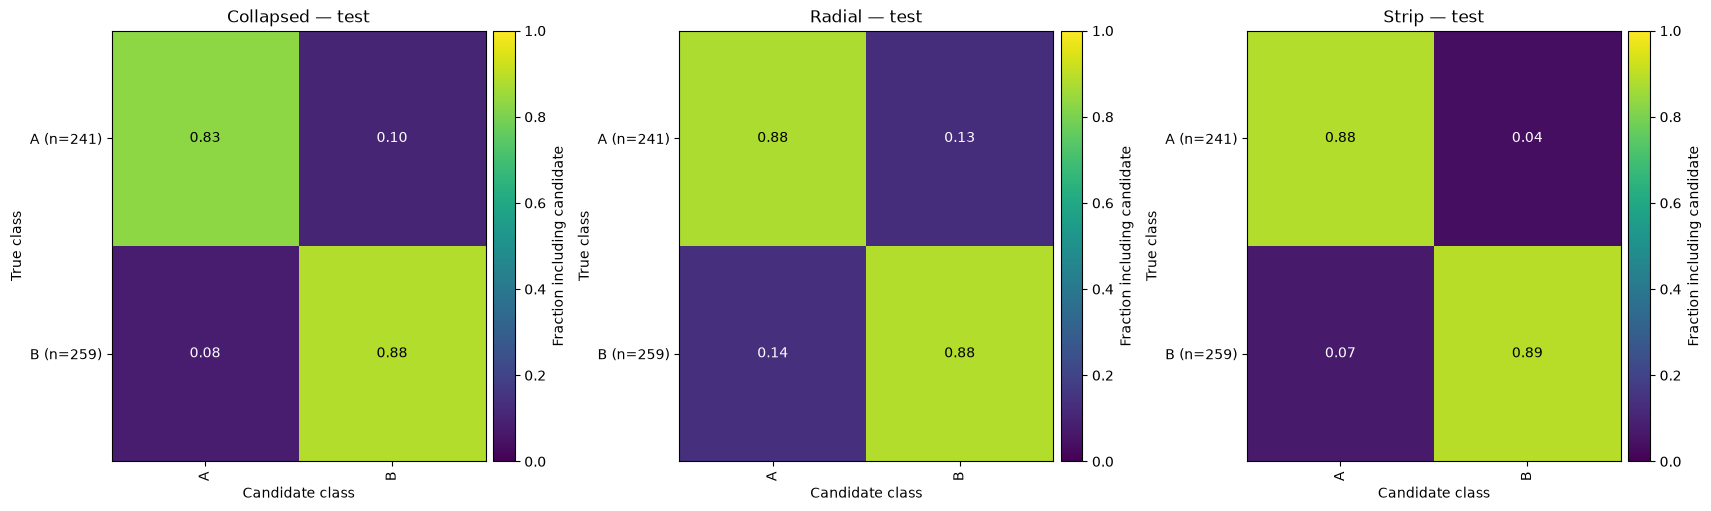

In [16]:
from conformal_envelopes import plot_inclusion_heatmap

fig, axes = plt.subplots(1, len(predictions), figsize=(17, 5), squeeze=False, 
                         constrained_layout=True,)

inclusion_tables = {}

for ax, (method, result) in zip(axes.ravel(), predictions.items()):
    # Match true labels to the prediction rows by ID.
    truth = (test.set_index("ID").loc[result["ID"], "label"].tolist())

    _, rates = plot_inclusion_heatmap(result["prediction_set"], truth, classes=CLASSES,
                                      ax=ax, title=f"{method.capitalize()} — test",
                                      annotate=True,)

    inclusion_tables[method] = rates

plt.show()

In [17]:
# Repeating the same experiment with five predefined seeds.
EXPERIMENT_SEEDS = [7, 21, 25, 73, 99]
experiment_rows = []

for run_seed in EXPERIMENT_SEEDS:
    # Independent training and test draws, shared across methods.
    run_train_seed, run_test_seed = np.random.SeedSequence(run_seed).spawn(2)

    run_train, _ = generate_data(N_TRAIN, np.random.default_rng(run_train_seed), "train")
    run_test, _ = generate_data(N_TEST, np.random.default_rng(run_test_seed), "test")

    for method, parameters in METHOD_PARAMS.items():
        run_model = ConformalSetModel(method=method, alpha=ALPHA, random_state=run_seed,
                                       score_direction="higher_is_better", shape_fraction=0.5,
                                         force_nonempty=False, **parameters,)

        start = perf_counter()
        run_model.fit(run_train, id_col="ID", label_col="label", score_cols=score_cols, 
                       label_to_columns=label_to_columns,)
        fit_seconds = perf_counter() - start

        start = perf_counter()
        run_predictions = run_model.predict(run_test.drop(columns="label"))
        predict_seconds = perf_counter() - start

        truth = (run_test.set_index("ID").loc[run_predictions["ID"], "label"].to_numpy())

        covered = np.array([true_label in prediction_set for true_label, prediction_set 
                            in zip(truth, run_predictions["prediction_set"])])
        sizes = run_predictions["set_size"].to_numpy()

        row = {"seed": run_seed, "method": method, "coverage": covered.mean(),
                "average_set_size": sizes.mean(), "singleton_rate": (sizes == 1).mean(),
                "empty_rate": (sizes == 0).mean(), "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,}

        for label in CLASSES:
            selected = truth == label
            row[f"coverage_{label}"] = (covered[selected].mean() if selected.any() else np.nan)

        experiment_rows.append(row)
        print(f"Seed {run_seed} | {method}: " f"coverage={row['coverage']:.3f}, "
               f"set size={row['average_set_size']:.3f}")

experiment_results = pd.DataFrame(experiment_rows)

print("\nAll runs:")
display(experiment_results.round(4))

report_columns = ["coverage", *[f"coverage_{label}" for label in CLASSES], "average_set_size",
                   "singleton_rate", "empty_rate", "fit_seconds", "predict_seconds",]

experiment_summary = (experiment_results.groupby("method", sort=False)[report_columns].agg(["mean", "std"]))

print("\nMean and standard deviation across seeds:")
display(experiment_summary.round(4))
print(f"Nominal coverage target: {1 - ALPHA:.0%}")

Seed 7 | collapsed: coverage=0.910, set size=1.000
Seed 7 | radial: coverage=0.908, set size=1.032
Seed 7 | strip: coverage=0.898, set size=0.942
Seed 21 | collapsed: coverage=0.890, set size=1.010
Seed 21 | radial: coverage=0.914, set size=1.096
Seed 21 | strip: coverage=0.910, set size=0.970
Seed 25 | collapsed: coverage=0.894, set size=0.996
Seed 25 | radial: coverage=0.914, set size=1.082
Seed 25 | strip: coverage=0.904, set size=0.936
Seed 73 | collapsed: coverage=0.918, set size=1.058
Seed 73 | radial: coverage=0.896, set size=1.074
Seed 73 | strip: coverage=0.902, set size=0.974
Seed 99 | collapsed: coverage=0.926, set size=1.084
Seed 99 | radial: coverage=0.906, set size=1.122
Seed 99 | strip: coverage=0.924, set size=0.996

All runs:


,seed,method,coverage,average_set_size,singleton_rate,empty_rate,fit_seconds,predict_seconds,coverage_A,coverage_B
0,7,collapsed,0.910,1.000,0.844,0.078,0.0047,0.0291,0.9320,0.8880
1,7,radial,0.908,1.032,0.812,0.078,0.0532,0.0609,0.9200,0.8960
2,7,strip,0.898,0.942,0.870,0.094,0.0338,0.0299,0.9000,0.8960
3,21,collapsed,0.890,1.010,0.794,0.098,0.0043,0.0292,0.8704,0.9091
4,21,radial,0.914,1.096,0.760,0.072,0.0537,0.0641,0.8826,0.9447
5,21,strip,0.910,0.970,0.854,0.088,0.0337,0.0305,0.9028,0.9170
6,25,collapsed,0.894,0.996,0.824,0.090,0.0046,0.0304,0.9103,0.8797
7,25,radial,0.914,1.082,0.774,0.072,0.0560,0.0681,0.9274,0.9023
8,25,strip,0.904,0.936,0.880,0.092,0.0358,0.0318,0.9017,0.9060
9,73,collapsed,0.918,1.058,0.802,0.070,0.0050,0.0302,0.9283,0.9087



Mean and standard deviation across seeds:


coverage         coverage_A         coverage_B          \
              mean     std       mean     std       mean     std   
method                                                             
collapsed   0.9076  0.0154     0.9120  0.0247     0.9038  0.0210   
radial      0.9076  0.0074     0.9018  0.0214     0.9140  0.0235   
strip       0.9076  0.0101     0.9004  0.0091     0.9146  0.0155   

          average_set_size         singleton_rate         empty_rate          \
                      mean     std           mean     std       mean     std   
method                                                                         
collapsed           1.0296  0.0392         0.8104  0.0232     0.0800  0.0140   
radial              1.0812  0.0330         0.7636  0.0340     0.0776  0.0059   
strip               0.9636  0.0246         0.8604  0.0160     0.0880  0.0093   

          fit_seconds         predict_seconds          
                 mean     std            mean     std  
method                                                 
collapsed      0.0047  0.0002          0.0296  0.0006  
radial         0.0540  0.0012          0.0635  0.0029  
strip          0.0341  0.0010          0.0442  0.0299

Nominal coverage target: 90%
